In [2]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import Input, Model, layers
from tensorflow.keras.layers import Dense, Concatenate
from tensorflow.keras.regularizers import Regularizer
from tensorflow.keras import regularizers
import scipy.stats as ss
from scipy.linalg import null_space
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

In [19]:
# Load the data from csv files
df = pd.read_csv("../test_files/test_4ring_long_seq/test_4ring.csv")
ka_mat = np.loadtxt("../test_files/test_4ring_long_seq/test_4ring_ka_mat.nptxt")
ka_contrib = np.loadtxt("../test_files/test_4ring_long_seq/test_4ring_rate_contrib_mat.nptxt")
x = df["seq"].values
y = df["raw_activity"].values

enc = OneHotEncoder(categories=[["A", "B"]], sparse=False)

# Encode sequences as one-hot vectors
n_samples = len(x)
seq_length = len(x[0])  # Assuming all sequences have the same length
flat = np.array([list(seq) for seq in x]).flatten()[:, None]
encoded = enc.fit_transform(flat)
x = encoded.reshape(n_samples, seq_length, 2)  # shape: (n_samples, seq_length, 2)
print(ka_mat)

[[0. 1. 0. 1. 0. 0. 1.]
 [0. 1. 0. 0. 1. 0. 1.]
 [0. 0. 1. 0. 1. 0. 1.]
 [0. 1. 0. 1. 0. 1. 0.]
 [1. 0. 0. 1. 0. 0. 1.]
 [1. 0. 0. 0. 1. 0. 1.]
 [1. 0. 0. 1. 0. 1. 0.]
 [1. 0. 1. 0. 0. 0. 1.]
 [1. 0. 1. 0. 0. 1. 0.]
 [1. 0. 1. 0. 1. 0. 0.]]


In [20]:
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=777
)

In [21]:
# No regularizations
inputs = layers.Input(shape=(seq_length, 2))  # one-hot encoded 'A'/'B' per position
flat = layers.Flatten()(inputs)  # flatten the input
log_rates = layers.Dense(
    7, activation="linear", name="log_rates", 
    )(flat)  # hidden layer
KA_terms = layers.Lambda(
    lambda x: tf.nn.softmax(
        tf.matmul(x, tf.constant(ka_mat, dtype=tf.float32), transpose_b=True)
    ),
    name="KA_terms",
)(log_rates)
print(ka_mat.shape)
print(ka_contrib.shape)

# Corrected Lambda for contrib_KA_terms
contrib_KA_terms = layers.Lambda(
    lambda x: tf.matmul(x, tf.constant(ka_contrib, dtype=tf.float32), transpose_b=True),
    name="contrib_KA_terms",
)(KA_terms)
exp_rates = layers.Lambda(lambda x: tf.exp(x), name="exp_log_rates")(log_rates)
output = layers.Dot(axes=1, name="dot_output")([contrib_KA_terms, exp_rates])
model = Model(inputs=inputs, outputs=output)


model.compile(optimizer="adam", loss="mse")

# Train the model
hist = model.fit(
    x_train, y_train, epochs=500, batch_size=32, validation_data=(x_test, y_test)
)


(10, 7)
(7, 10)
Train on 800 samples, validate on 200 samples
Epoch 1/500
800/800 [==============================] - 0s 308us/sample - loss: 0.0318 - val_loss: 0.0144
Epoch 2/500
800/800 [==============================] - 0s 29us/sample - loss: 0.0066 - val_loss: 0.0037
Epoch 3/500
800/800 [==============================] - 0s 27us/sample - loss: 0.0019 - val_loss: 0.0015
Epoch 4/500
800/800 [==============================] - 0s 28us/sample - loss: 8.8300e-04 - val_loss: 8.1278e-04
Epoch 5/500
800/800 [==============================] - 0s 28us/sample - loss: 5.5370e-04 - val_loss: 5.3394e-04
Epoch 6/500
800/800 [==============================] - 0s 26us/sample - loss: 4.0458e-04 - val_loss: 3.9119e-04
Epoch 7/500
800/800 [==============================] - 0s 27us/sample - loss: 3.2475e-04 - val_loss: 3.1085e-04
Epoch 8/500
800/800 [==============================] - 0s 30us/sample - loss: 2.7938e-04 - val_loss: 2.5703e-04
Epoch 9/500
800/800 [==============================] - 0s 28us/sa

Exp Biases: [0.7803394  0.6891528  0.7862496  0.8994731  0.8394913  0.9451528  0.81965363]
Weights:
 [[ 1.19395129e-01 -3.76863807e-01  2.92781949e-01 -1.75877616e-01 -5.82095683e-02 -1.29141249e-02  1.18491143e-01]
 [-4.51663405e-01 -2.66952123e-02  1.25715196e-01  2.43181869e-01 -2.64068782e-01 -1.68924645e-01  1.78388923e-01]
 [ 5.73041327e-02 -1.78943545e-01  3.11343074e-01  1.73578620e-01 -1.88333601e-01  1.96955413e-01  1.85144156e-01]
 [-2.93678015e-01  4.15057689e-01 -4.05214429e-01  8.77706856e-02  7.04017282e-02  2.20280383e-02 -2.18214259e-01]
 [ 5.45008294e-02 -2.02740356e-01 -2.16739312e-01  4.01911318e-01  2.85610825e-01 -4.31837626e-02 -3.22801322e-01]
 [-5.32869160e-01  3.71117979e-01 -2.89295673e-01  4.04845297e-01  1.89979196e-01  2.21218884e-01 -3.51874262e-01]
 [ 6.21256121e-02 -7.52492175e-02 -2.10057646e-01  1.76359564e-01 -8.77515227e-02 -9.63798463e-02  1.21139893e-02]
 [-3.31626564e-01  7.50330746e-01 -4.05632317e-01  6.94157481e-01 -1.05217658e-01  1.50980428e

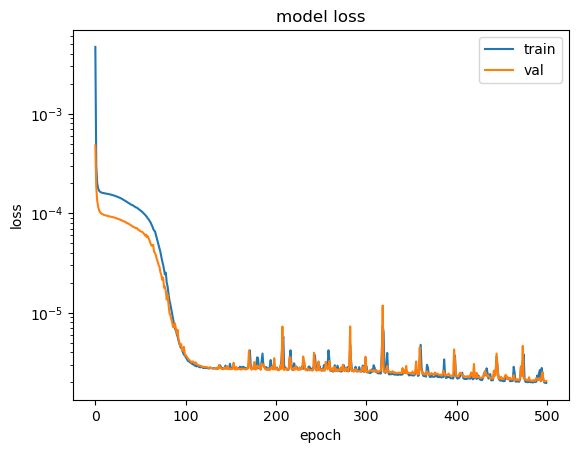

In [ ]:
plt.plot(hist.history["loss"])
plt.plot(hist.history["val_loss"])
plt.title("model loss")
plt.ylabel("loss")
plt.xlabel("epoch")
plt.legend(["train", "val"])
plt.yscale("log")
np.set_printoptions(linewidth=np.inf)
layer = model.get_layer("log_rates")  # or model.layers[0]
weights, biases = layer.get_weights()

print("Exp Biases:", np.exp(biases))
weights = np.array(weights)
print("Weights:\n", weights)
print("Max weights:", np.max(weights.T, axis=1))
# print("Exp Weights:\n", np.exp(weights))
x = np.array([[1, 0]] * seq_length).reshape(1, seq_length, 2)  # Template input
activation = Model(inputs=model.input, outputs=model.get_layer("log_rates").output)
activation_output = activation.predict(x)
print("Matching Rates:", np.exp(activation_output))
y = model.predict(x)
print("Activity:", y)
xoff = x.copy()
xoff[:,0]=np.array([0,1])
print("Missmatching Rates:", np.exp(activation.predict(xoff)))
print("Missmatch activity:", model.predict(xoff))

In [ ]:
# No regularizations
inputs = layers.Input(shape=(seq_length, 2))  # one-hot encoded 'A'/'B' per position
flat = layers.Flatten()(inputs)  # flatten the input
log_rates = layers.Dense(
    7, activation="linear", name="log_rates",
    use_bias=False,  # Ensure bias is used 
    )(flat)  # hidden layer
KA_terms = layers.Lambda(
    lambda x: tf.nn.softmax(
        tf.matmul(x, tf.constant(ka_mat, dtype=tf.float32), transpose_b=True)
    ),
    name="KA_terms",
)(log_rates)
print(ka_mat.shape)
print(ka_contrib.shape)

# Corrected Lambda for contrib_KA_terms
contrib_KA_terms = layers.Lambda(
    lambda x: tf.matmul(x, tf.constant(ka_contrib, dtype=tf.float32), transpose_b=True),
    name="contrib_KA_terms",
)(KA_terms)
exp_rates = layers.Lambda(lambda x: tf.exp(x), name="exp_log_rates")(log_rates)
output = layers.Dot(axes=1, name="dot_output")([contrib_KA_terms, exp_rates])
model = Model(inputs=inputs, outputs=output)


model.compile(optimizer="adam", loss="mse")

# Train the model
hist = model.fit(
    x_train, y_train, epochs=500, batch_size=16, validation_data=(x_test, y_test)
)


(10, 7)
(7, 10)
Train on 800 samples, validate on 200 samples
Epoch 1/500
800/800 [==============================] - 0s 560us/sample - loss: 4.6880e-04 - val_loss: 1.1124e-04
Epoch 2/500
800/800 [==============================] - 0s 27us/sample - loss: 1.6752e-04 - val_loss: 9.8181e-05
Epoch 3/500
800/800 [==============================] - 0s 27us/sample - loss: 1.6278e-04 - val_loss: 9.7026e-05
Epoch 4/500
800/800 [==============================] - 0s 26us/sample - loss: 1.6178e-04 - val_loss: 9.6445e-05
Epoch 5/500
800/800 [==============================] - 0s 28us/sample - loss: 1.6093e-04 - val_loss: 9.5991e-05
Epoch 6/500
800/800 [==============================] - 0s 28us/sample - loss: 1.6009e-04 - val_loss: 9.5491e-05
Epoch 7/500
800/800 [==============================] - 0s 29us/sample - loss: 1.5917e-04 - val_loss: 9.4969e-05
Epoch 8/500
800/800 [==============================] - 0s 28us/sample - loss: 1.5807e-04 - val_loss: 9.4483e-05
Epoch 9/500
800/800 [====================

Weights:
 [[[-0.06776953 -0.3425009   0.0588143   0.12887654  0.11306176  0.3363674  -0.00619938]
  [-0.21919782  0.32815677 -0.13205431 -0.03915905 -0.08069851  0.14090802 -0.29908782]
  [ 0.08035853  0.22098236 -0.2274314   0.1300724  -0.15904921  0.10460261 -0.05284939]
  [-0.42918247  0.48162377 -0.0052545   0.15968144 -0.04812964  0.52639014 -0.36502424]
  [-0.21833117 -0.38152143 -0.12277232  0.02603596 -0.13831493 -0.00885282 -0.18914928]
  [-0.03864395  0.5316711  -0.10872433  0.27546763  0.09287746  0.3171165  -0.34381217]
  [ 0.36463222 -0.0368508  -0.22464928  0.36732104  0.04011622 -0.16317947  0.12316035]
  [-0.2465639   0.46702507  0.07243936  0.2852948  -0.3174158   0.33897698 -0.31399587]
  [ 0.05886923 -0.21859501  0.06239507 -0.11277112 -0.15243582 -0.15611541 -0.1291445 ]
  [-0.46617097  0.60129344  0.09078066 -0.07309076 -0.33141398  0.2875822  -0.27034009]
  [ 0.16215615 -0.20175014  0.23147595  0.16042647 -0.2114043  -0.19318953  0.31648287]
  [-0.32814223 -0.0077

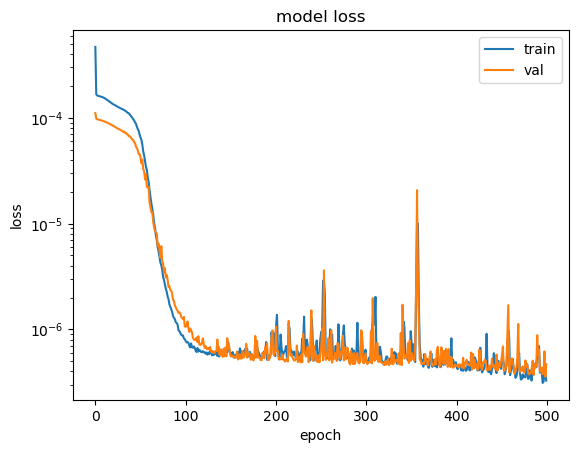

In [38]:
plt.plot(hist.history["loss"])
plt.plot(hist.history["val_loss"])
plt.title("model loss")
plt.ylabel("loss")
plt.xlabel("epoch")
plt.legend(["train", "val"])
plt.yscale("log")
np.set_printoptions(linewidth=np.inf)
layer = model.get_layer("log_rates")  # or model.layers[0]
# weights, biases = layer.get_weights()
weights = layer.get_weights()

# print("Exp Biases:", np.exp(biases))
weights = np.array(weights)
print("Weights:\n", weights)
print("Max weights:", np.max(weights.T, axis=1))
# print("Exp Weights:\n", np.exp(weights))
x = np.array([[1, 0]] * seq_length).reshape(1, seq_length, 2)  # Template input
activation = Model(inputs=model.input, outputs=model.get_layer("log_rates").output)
activation_output = activation.predict(x)
print("Matching Rates:", np.exp(activation_output))
y = model.predict(x)
print("Activity:", y)
xoff = x.copy()
xoff[:,0]=np.array([0,1])
print("Missmatching Rates:", np.exp(activation.predict(xoff)))
print("Missmatch activity:", model.predict(xoff))

In [39]:
# Regularize based on the rates with L1 norm on the exponent of the rate matrix
class LogRateRegularize(Regularizer):
    def __init__(self, coeff=1e-4):
        self.coeff = coeff

    def __call__(self, x):
        # Here x is the ACTIVATION output of the layer
        # Example: L1 norm on activations
        return self.coeff * tf.reduce_sum(tf.exp(x))

    def get_config(self):
        return {'coeff': float(self.coeff)}

inputs = layers.Input(shape=(seq_length, 2))  # one-hot encoded 'A'/'B' per position
flat = layers.Flatten()(inputs)  # flatten the input
log_rates = layers.Dense(
    7, activation="linear", name="log_rates", 
    kernel_regularizer=LogRateRegularize(1e-7),
    use_bias=False)(flat)  # hidden layer
KA_terms = layers.Lambda(
    lambda x: tf.nn.softmax(
        tf.matmul(x, tf.constant(ka_mat, dtype=tf.float32), transpose_b=True)
    ),
    name="KA_terms",
)(log_rates)
print(ka_mat.shape)
print(ka_contrib.shape)

# Corrected Lambda for contrib_KA_terms
contrib_KA_terms = layers.Lambda(
    lambda x: tf.matmul(x, tf.constant(ka_contrib, dtype=tf.float32), transpose_b=True),
    name="contrib_KA_terms",
)(KA_terms)
exp_rates = layers.Lambda(lambda x: tf.exp(x), name="exp_log_rates")(log_rates)
output = layers.Dot(axes=1, name="dot_output")([contrib_KA_terms, exp_rates])
model = Model(inputs=inputs, outputs=output)


model.compile(optimizer="adam", loss="mse")

# Train the model
hist = model.fit(
    x_train, y_train, epochs=500, batch_size=16, validation_data=(x_test, y_test)
)


(10, 7)
(7, 10)
Train on 800 samples, validate on 200 samples
Epoch 1/500
800/800 [==============================] - 0s 561us/sample - loss: 0.0096 - val_loss: 0.0015
Epoch 2/500
800/800 [==============================] - 0s 53us/sample - loss: 6.8499e-04 - val_loss: 4.3793e-04
Epoch 3/500
800/800 [==============================] - 0s 49us/sample - loss: 3.0415e-04 - val_loss: 2.5738e-04
Epoch 4/500
800/800 [==============================] - 0s 53us/sample - loss: 2.2470e-04 - val_loss: 1.9481e-04
Epoch 5/500
800/800 [==============================] - 0s 53us/sample - loss: 1.9660e-04 - val_loss: 1.6461e-04
Epoch 6/500
800/800 [==============================] - 0s 55us/sample - loss: 1.8360e-04 - val_loss: 1.5019e-04
Epoch 7/500
800/800 [==============================] - 0s 53us/sample - loss: 1.7725e-04 - val_loss: 1.4089e-04
Epoch 8/500
800/800 [==============================] - 0s 52us/sample - loss: 1.7361e-04 - val_loss: 1.3489e-04
Epoch 9/500
800/800 [============================

Weights:
 [[[-0.12538144 -0.10767903 -0.18423088 -0.33252335 -0.0799856  -1.1862478  -0.2319521 ]
  [-0.333085   -0.44087175 -0.7806948   0.03135989 -0.85321337 -1.8527136  -0.622889  ]
  [-0.41981044 -0.16195637  0.0384151  -0.44980726  0.02030464 -1.1989684  -0.11117681]
  [-0.6043958  -0.5706651  -0.6722648  -0.13764209 -0.62044835 -1.787319   -0.5882142 ]
  [-0.3561251  -0.06510251  0.15888852 -0.32674262 -0.18943721 -1.3045527  -0.31251463]
  [-0.50986964 -0.5452502  -0.6789177  -0.13125081 -0.84718883 -1.9725524  -0.7852704 ]
  [-0.11263763 -0.2054069  -0.2251102  -0.44329485  0.2067073  -1.236703   -0.12802695]
  [-0.97940063 -0.4177386  -1.0419427  -0.22850889 -1.1237363  -2.0204535  -1.0294377 ]
  [-0.29745495 -0.3572724   0.02805755 -0.19571279  0.02826909 -1.2163774  -0.1988106 ]
  [-0.92076737 -0.32624403 -0.98453003 -0.19047616 -1.3191915  -2.0410693  -1.2065349 ]
  [-0.06495665 -0.26672143 -0.01395342 -0.05351347 -0.16157547 -1.3191799  -0.16065833]
  [-0.94548434 -0.5428

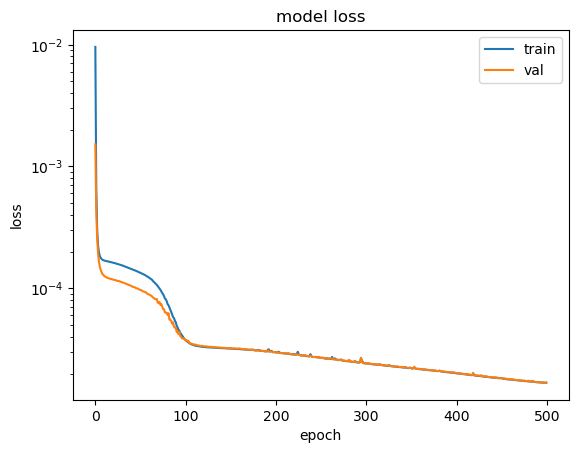

In [41]:
plt.plot(hist.history["loss"])
plt.plot(hist.history["val_loss"])
plt.title("model loss")
plt.ylabel("loss")
plt.xlabel("epoch")
plt.legend(["train", "val"])
plt.yscale("log")
np.set_printoptions(linewidth=np.inf)
layer = model.get_layer("log_rates")  # or model.layers[0]
# weights, biases = layer.get_weights()
weights = layer.get_weights()

# print("Exp Biases:", np.exp(biases))
weights = np.array(weights)
print("Weights:\n", weights)
print("Max weights:", np.max(weights.T, axis=1))
# print("Exp Weights:\n", np.exp(weights))
x = np.array([[1, 0]] * seq_length).reshape(1, seq_length, 2)  # Template input
activation = Model(inputs=model.input, outputs=model.get_layer("log_rates").output)
activation_output = activation.predict(x)
print("Matching Rates:", np.exp(activation_output))
y = model.predict(x)
print("Activity:", y)
xoff = x.copy()
xoff[:,0]=np.array([0,1])
print("Missmatching Rates:", np.exp(activation.predict(xoff)))
print("Missmatch activity:", model.predict(xoff))
print(weights.shape)

In [ ]:
# Regularize based on the rates with L1 norm on the exponent of the rate matrix
class LogRateRegularize(Regularizer):
    def __init__(self, coeff=1e-4):
        self.coeff = coeff

    def __call__(self, x):
        # Here x is the ACTIVATION output of the layer
        # Example: L1 norm on activations
        return self.coeff * tf.reduce_sum(tf.exp(x))

    def get_config(self):
        return {'coeff': float(self.coeff)}

inputs = layers.Input(shape=(seq_length, 2))  # one-hot encoded 'A'/'B' per position
flat = layers.Flatten()(inputs)  # flatten the input
log_rates = layers.Dense(
    7, activation="linear", name="log_rates", kernel_regularizer=LogRateRegularize(1e-7))(flat)  # hidden layer
KA_terms = layers.Lambda(
    lambda x: tf.nn.softmax(
        tf.matmul(x, tf.constant(ka_mat, dtype=tf.float32), transpose_b=True)
    ),
    name="KA_terms",
)(log_rates)
print(ka_mat.shape)
print(ka_contrib.shape)

# Corrected Lambda for contrib_KA_terms
contrib_KA_terms = layers.Lambda(
    lambda x: tf.matmul(x, tf.constant(ka_contrib, dtype=tf.float32), transpose_b=True),
    name="contrib_KA_terms",
)(KA_terms)
exp_rates = layers.Lambda(lambda x: tf.exp(x), name="exp_log_rates")(log_rates)
output = layers.Dot(axes=1, name="dot_output")([contrib_KA_terms, exp_rates])
model = Model(inputs=inputs, outputs=output)


model.compile(optimizer="adam", loss="mse")

# Train the model
hist = model.fit(
    x_train, y_train, epochs=500, batch_size=32, validation_data=(x_test, y_test)
)


(10, 7)
(7, 10)
Train on 800 samples, validate on 200 samples
Epoch 1/500
800/800 [==============================] - 0s 425us/sample - loss: 0.0017 - val_loss: 4.2311e-04
Epoch 2/500
800/800 [==============================] - 0s 35us/sample - loss: 3.3309e-04 - val_loss: 1.9667e-04
Epoch 3/500
800/800 [==============================] - 0s 30us/sample - loss: 2.3633e-04 - val_loss: 1.5993e-04
Epoch 4/500
800/800 [==============================] - 0s 28us/sample - loss: 2.1548e-04 - val_loss: 1.4626e-04
Epoch 5/500
800/800 [==============================] - 0s 29us/sample - loss: 2.0584e-04 - val_loss: 1.4013e-04
Epoch 6/500
800/800 [==============================] - 0s 27us/sample - loss: 2.0115e-04 - val_loss: 1.3599e-04
Epoch 7/500
800/800 [==============================] - 0s 28us/sample - loss: 1.9824e-04 - val_loss: 1.3323e-04
Epoch 8/500
800/800 [==============================] - 0s 28us/sample - loss: 1.9625e-04 - val_loss: 1.3155e-04
Epoch 9/500
800/800 [========================

In [25]:
# Regularize based on the rates with L1 norm on the exponent of the rate matrix
class LogRateL1Regularize(Regularizer):
    def __init__(self, coeff=1e-4):
        self.coeff = coeff

    def __call__(self, x):
        return self.coeff * tf.reduce_mean(tf.exp(x))

    def get_config(self):
        return {'coeff': float(self.coeff)}

inputs = layers.Input(shape=(seq_length, 2))  # one-hot encoded 'A'/'B' per position
flat = layers.Flatten()(inputs)  # flatten the input
log_rates = layers.Dense(
    7, activation="linear", name="log_rates", 
    kernel_regularizer=LogRateL1Regularize(1e-6), 
    bias_regularizer=LogRateL1Regularize(1e-6), 
    # activity_regularizer=LogRateL1Regularize(1e-6), 
    )(flat)  # hidden layer
KA_terms = layers.Lambda(
    lambda x: tf.nn.softmax(
        tf.matmul(x, tf.constant(ka_mat, dtype=tf.float32), transpose_b=True)
    ),
    name="KA_terms",
)(log_rates)
print(ka_mat.shape)
print(ka_contrib.shape)

# Corrected Lambda for contrib_KA_terms
contrib_KA_terms = layers.Lambda(
    lambda x: tf.matmul(x, tf.constant(ka_contrib, dtype=tf.float32), transpose_b=True),
    name="contrib_KA_terms",
)(KA_terms)
exp_rates = layers.Lambda(lambda x: tf.exp(x), name="exp_log_rates")(log_rates)
output = layers.Dot(axes=1, name="dot_output")([contrib_KA_terms, exp_rates])
model = Model(inputs=inputs, outputs=output)


model.compile(optimizer="adam", loss="mse")

# Train the model
hist = model.fit(
    x_train, y_train, epochs=500, batch_size=16, validation_data=(x_test, y_test)
)


(10, 7)
(7, 10)
Train on 800 samples, validate on 200 samples
Epoch 1/500
800/800 [==============================] - 0s 419us/sample - loss: 0.0047 - val_loss: 4.7787e-04
Epoch 2/500
800/800 [==============================] - 0s 54us/sample - loss: 3.0053e-04 - val_loss: 1.8434e-04
Epoch 3/500
800/800 [==============================] - 0s 50us/sample - loss: 2.0144e-04 - val_loss: 1.3439e-04
Epoch 4/500
800/800 [==============================] - 0s 53us/sample - loss: 1.7783e-04 - val_loss: 1.1702e-04
Epoch 5/500
800/800 [==============================] - 0s 51us/sample - loss: 1.6884e-04 - val_loss: 1.0771e-04
Epoch 6/500
800/800 [==============================] - 0s 54us/sample - loss: 1.6441e-04 - val_loss: 1.0297e-04
Epoch 7/500
800/800 [==============================] - 0s 50us/sample - loss: 1.6200e-04 - val_loss: 1.0030e-04
Epoch 8/500
800/800 [==============================] - 0s 49us/sample - loss: 1.6057e-04 - val_loss: 9.8321e-05
Epoch 9/500
800/800 [========================

Exp Biases: [0.7803394  0.6891528  0.7862496  0.8994731  0.8394913  0.9451528  0.81965363]
Weights:
 [[ 1.19395129e-01 -3.76863807e-01  2.92781949e-01 -1.75877616e-01 -5.82095683e-02 -1.29141249e-02  1.18491143e-01]
 [-4.51663405e-01 -2.66952123e-02  1.25715196e-01  2.43181869e-01 -2.64068782e-01 -1.68924645e-01  1.78388923e-01]
 [ 5.73041327e-02 -1.78943545e-01  3.11343074e-01  1.73578620e-01 -1.88333601e-01  1.96955413e-01  1.85144156e-01]
 [-2.93678015e-01  4.15057689e-01 -4.05214429e-01  8.77706856e-02  7.04017282e-02  2.20280383e-02 -2.18214259e-01]
 [ 5.45008294e-02 -2.02740356e-01 -2.16739312e-01  4.01911318e-01  2.85610825e-01 -4.31837626e-02 -3.22801322e-01]
 [-5.32869160e-01  3.71117979e-01 -2.89295673e-01  4.04845297e-01  1.89979196e-01  2.21218884e-01 -3.51874262e-01]
 [ 6.21256121e-02 -7.52492175e-02 -2.10057646e-01  1.76359564e-01 -8.77515227e-02 -9.63798463e-02  1.21139893e-02]
 [-3.31626564e-01  7.50330746e-01 -4.05632317e-01  6.94157481e-01 -1.05217658e-01  1.50980428e

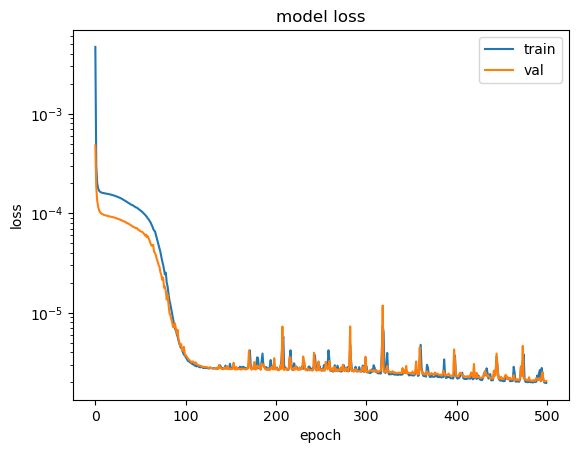

In [28]:
plt.plot(hist.history["loss"])
plt.plot(hist.history["val_loss"])
plt.title("model loss")
plt.ylabel("loss")
plt.xlabel("epoch")
plt.legend(["train", "val"])
plt.yscale("log")
np.set_printoptions(linewidth=np.inf)
layer = model.get_layer("log_rates")  # or model.layers[0]
weights, biases = layer.get_weights()

print("Exp Biases:", np.exp(biases))
weights = np.array(weights)
print("Weights:\n", weights)
print("Max weights:", np.max(weights.T, axis=1))
# print("Exp Weights:\n", np.exp(weights))
x = np.array([[1, 0]] * seq_length).reshape(1, seq_length, 2)  # Template input
activation = Model(inputs=model.input, outputs=model.get_layer("log_rates").output)
activation_output = activation.predict(x)
print("Matching Rates:", np.exp(activation_output))
y = model.predict(x)
print("Activity:", y)
xoff = x.copy()
xoff[:,0]=np.array([0,1])
print("Missmatching Rates:", np.exp(activation.predict(xoff)))
print("Missmatch activity:", model.predict(xoff))

In [32]:
# Regularize based on the rates with L1 norm on the exponent of the rate matrix
class LogRateL1SumRegularize(Regularizer):
    def __init__(self, coeff=1e-4):
        self.coeff = coeff

    def __call__(self, x):
        return self.coeff * tf.reduce_sum(tf.exp(x))

    def get_config(self):
        return {'coeff': float(self.coeff)}

inputs = layers.Input(shape=(seq_length, 2))  # one-hot encoded 'A'/'B' per position
flat = layers.Flatten()(inputs)  # flatten the input
log_rates = layers.Dense(
    7, activation="linear", name="log_rates", 
    kernel_regularizer=LogRateL1SumRegularize(1e-7), 
    bias_regularizer=LogRateL1SumRegularize(1e-7), 
    # activity_regularizer=LogRateL1SumRegularize(1e-6), 
    )(flat)  # hidden layer
KA_terms = layers.Lambda(
    lambda x: tf.nn.softmax(
        tf.matmul(x, tf.constant(ka_mat, dtype=tf.float32), transpose_b=True)
    ),
    name="KA_terms",
)(log_rates)
print(ka_mat.shape)
print(ka_contrib.shape)

# Corrected Lambda for contrib_KA_terms
contrib_KA_terms = layers.Lambda(
    lambda x: tf.matmul(x, tf.constant(ka_contrib, dtype=tf.float32), transpose_b=True),
    name="contrib_KA_terms",
)(KA_terms)
exp_rates = layers.Lambda(lambda x: tf.exp(x), name="exp_log_rates")(log_rates)
output = layers.Dot(axes=1, name="dot_output")([contrib_KA_terms, exp_rates])
model = Model(inputs=inputs, outputs=output)


model.compile(optimizer="adam", loss="mse")

# Train the model
hist = model.fit(
    x_train, y_train, epochs=500, batch_size=16, validation_data=(x_test, y_test)
)


(10, 7)
(7, 10)
Train on 800 samples, validate on 200 samples
Epoch 1/500
800/800 [==============================] - 0s 487us/sample - loss: 1.9885e-04 - val_loss: 1.2474e-04
Epoch 2/500
800/800 [==============================] - 0s 55us/sample - loss: 1.8687e-04 - val_loss: 1.2258e-04
Epoch 3/500
800/800 [==============================] - 0s 50us/sample - loss: 1.8139e-04 - val_loss: 1.1843e-04
Epoch 4/500
800/800 [==============================] - 0s 50us/sample - loss: 1.7425e-04 - val_loss: 1.1423e-04
Epoch 5/500
800/800 [==============================] - 0s 51us/sample - loss: 1.6580e-04 - val_loss: 1.1085e-04
Epoch 6/500
800/800 [==============================] - 0s 53us/sample - loss: 1.5854e-04 - val_loss: 1.0598e-04
Epoch 7/500
800/800 [==============================] - 0s 50us/sample - loss: 1.5228e-04 - val_loss: 1.0303e-04
Epoch 8/500
800/800 [==============================] - 0s 52us/sample - loss: 1.4664e-04 - val_loss: 1.0431e-04
Epoch 9/500
800/800 [====================

Exp Biases: [0.9141531  0.15340571 1.0168321  0.333437   0.9264617  0.6478574  0.89602697]
Weights:
 [[-4.43983823e-01 -1.91675198e+00 -5.49271842e-03 -1.18245387e+00  1.02033183e-01 -7.76959896e-01  2.18329802e-01]
 [-3.67929101e-01 -2.23484778e+00 -8.77280056e-01 -1.45911777e+00 -8.20691526e-01 -8.32530856e-01 -8.35949659e-01]
 [-4.16560262e-01 -1.86797035e+00 -1.64881125e-01 -1.30921304e+00 -1.18335545e-01 -5.86767375e-01  1.77891448e-01]
 [-4.00875986e-01 -2.26794457e+00 -9.93270874e-01 -1.43074656e+00 -1.00022078e+00 -9.42452788e-01 -8.85032535e-01]
 [-3.42427135e-01 -1.88555050e+00  5.59226098e-03 -1.19143736e+00  3.71575654e-02 -5.15556097e-01 -1.69460997e-01]
 [-3.11622441e-01 -2.21591353e+00 -8.56287718e-01 -1.49090981e+00 -1.03902709e+00 -9.48912501e-01 -1.06069231e+00]
 [-2.92874634e-01 -1.86637175e+00 -7.68888146e-02 -1.30741298e+00  1.67118728e-01 -6.57847762e-01  1.81639288e-02]
 [-8.23234677e-01 -2.26949906e+00 -1.40126789e+00 -1.52283370e+00 -1.49383461e+00 -7.72227347e

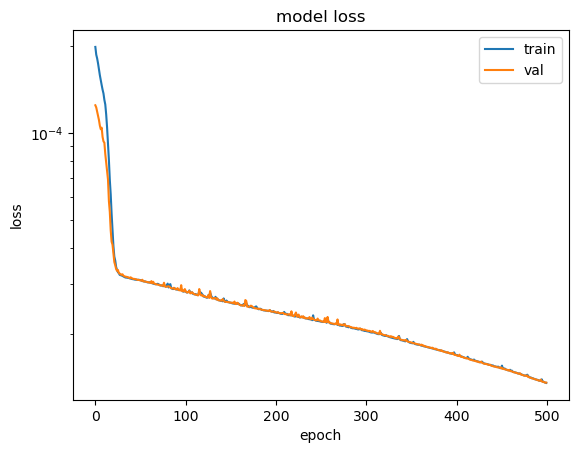

In [33]:
plt.plot(hist.history["loss"])
plt.plot(hist.history["val_loss"])
plt.title("model loss")
plt.ylabel("loss")
plt.xlabel("epoch")
plt.legend(["train", "val"])
plt.yscale("log")
np.set_printoptions(linewidth=np.inf)
layer = model.get_layer("log_rates")  # or model.layers[0]
weights, biases = layer.get_weights()

print("Exp Biases:", np.exp(biases))
weights = np.array(weights)
print("Weights:\n", weights)
print("Max weights:", np.max(weights.T, axis=1))
# print("Exp Weights:\n", np.exp(weights))
x = np.array([[1, 0]] * seq_length).reshape(1, seq_length, 2)  # Template input
activation = Model(inputs=model.input, outputs=model.get_layer("log_rates").output)
activation_output = activation.predict(x)
print("Matching Rates:", np.exp(activation_output))
y = model.predict(x)
print("Activity:", y)
xoff = x.copy()
xoff[:,0]=np.array([0,1])
print("Missmatching Rates:", np.exp(activation.predict(xoff)))
print("Missmatch activity:", model.predict(xoff))

In [34]:
# Regularize based on the rates with L1 norm on the exponent of the rate matrix

inputs = layers.Input(shape=(seq_length, 2))  # one-hot encoded 'A'/'B' per position
flat = layers.Flatten()(inputs)  # flatten the input
log_rates = layers.Dense(
    7, activation="linear", name="log_rates", 
    kernel_regularizer=regularizers.l1(1e-6), 
    bias_regularizer=regularizers.l1(1e-6), 
    # activity_regularizer=LogRateL1SumRegularize(1e-6), 
    )(flat)  # hidden layer
KA_terms = layers.Lambda(
    lambda x: tf.nn.softmax(
        tf.matmul(x, tf.constant(ka_mat, dtype=tf.float32), transpose_b=True)
    ),
    name="KA_terms",
)(log_rates)
print(ka_mat.shape)
print(ka_contrib.shape)

# Corrected Lambda for contrib_KA_terms
contrib_KA_terms = layers.Lambda(
    lambda x: tf.matmul(x, tf.constant(ka_contrib, dtype=tf.float32), transpose_b=True),
    name="contrib_KA_terms",
)(KA_terms)
exp_rates = layers.Lambda(lambda x: tf.exp(x), name="exp_log_rates")(log_rates)
output = layers.Dot(axes=1, name="dot_output")([contrib_KA_terms, exp_rates])
model = Model(inputs=inputs, outputs=output)


model.compile(optimizer="adam", loss="mse")

# Train the model
hist = model.fit(
    x_train, y_train, epochs=500, batch_size=32, validation_data=(x_test, y_test)
)


(10, 7)
(7, 10)
Train on 800 samples, validate on 200 samples
Epoch 1/500
800/800 [==============================] - 0s 507us/sample - loss: 0.0024 - val_loss: 6.2997e-04
Epoch 2/500
800/800 [==============================] - 0s 30us/sample - loss: 4.6130e-04 - val_loss: 2.3152e-04
Epoch 3/500
800/800 [==============================] - 0s 31us/sample - loss: 2.8124e-04 - val_loss: 1.8354e-04
Epoch 4/500
800/800 [==============================] - 0s 29us/sample - loss: 2.4987e-04 - val_loss: 1.6851e-04
Epoch 5/500
800/800 [==============================] - 0s 29us/sample - loss: 2.3773e-04 - val_loss: 1.6158e-04
Epoch 6/500
800/800 [==============================] - 0s 30us/sample - loss: 2.3146e-04 - val_loss: 1.5782e-04
Epoch 7/500
800/800 [==============================] - 0s 30us/sample - loss: 2.2761e-04 - val_loss: 1.5577e-04
Epoch 8/500
800/800 [==============================] - 0s 28us/sample - loss: 2.2538e-04 - val_loss: 1.5433e-04
Epoch 9/500
800/800 [========================

Exp Biases: [1.0012712  1.0002538  0.9994484  1.4141833  0.99942344 1.5055183  0.999234  ]
Weights:
 [[ 1.18487090e-01 -6.65638770e-04  5.85997440e-02  2.28533104e-01  8.94238427e-02  2.15125663e-04  1.25430501e-03]
 [-1.82663801e-03  1.84112694e-03 -7.43809948e-03  1.35336682e-01 -1.65538207e-01  2.93689430e-01 -1.72168165e-01]
 [ 1.86026748e-03 -3.93436989e-04  4.48473878e-02  7.62773007e-02  1.12357058e-01  9.62634105e-04  1.45015051e-03]
 [-2.63185659e-03  2.81588221e-03 -1.55640095e-01  1.01228490e-01 -1.38327494e-01  1.43622503e-01 -5.52668609e-02]
 [ 2.56670755e-03 -7.03075202e-04  1.43543456e-03  2.14654788e-01  1.83929049e-03  2.22330535e-04  1.33056799e-03]
 [ 1.09893829e-03 -1.23941817e-03 -2.63452269e-02  2.10596949e-01 -2.70496577e-01  2.62320340e-01 -2.51463622e-01]
 [ 1.55901269e-03 -1.27883904e-04  4.02589358e-04  1.79706840e-03  4.66714730e-04  1.55890943e-03  1.75761161e-04]
 [-3.24106100e-03  3.76004330e-03 -1.36923909e-01  2.77539790e-01 -4.85154361e-01  2.99898267e

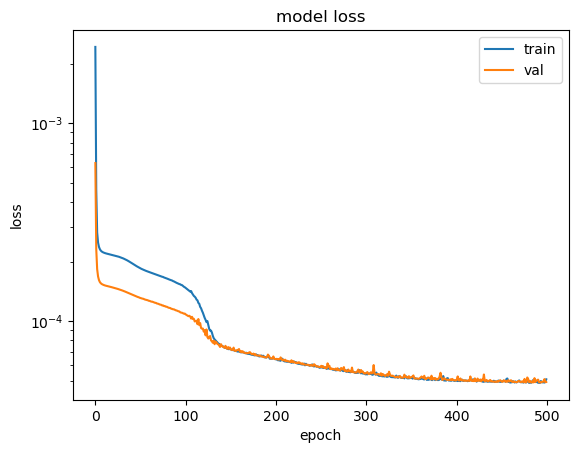

In [35]:
plt.plot(hist.history["loss"])
plt.plot(hist.history["val_loss"])
plt.title("model loss")
plt.ylabel("loss")
plt.xlabel("epoch")
plt.legend(["train", "val"])
plt.yscale("log")
np.set_printoptions(linewidth=np.inf)
layer = model.get_layer("log_rates")  # or model.layers[0]
weights, biases = layer.get_weights()

print("Exp Biases:", np.exp(biases))
weights = np.array(weights)
print("Weights:\n", weights)
print("Max weights:", np.max(weights.T, axis=1))
# print("Exp Weights:\n", np.exp(weights))
x = np.array([[1, 0]] * seq_length).reshape(1, seq_length, 2)  # Template input
activation = Model(inputs=model.input, outputs=model.get_layer("log_rates").output)
activation_output = activation.predict(x)
print("Matching Rates:", np.exp(activation_output))
y = model.predict(x)
print("Activity:", y)
xoff = x.copy()
xoff[:,0]=np.array([0,1])
print("Missmatching Rates:", np.exp(activation.predict(xoff)))
print("Missmatch activity:", model.predict(xoff))

In [49]:
# Regularize based on entropy of the rate matrix
class ColumnEntropyRegularizer(Regularizer):
    def __init__(self, coeff=1e-3):
        self.coeff = coeff
    def __call__(self, W):
        P = tf.nn.softmax(W, axis=1)  # normalize columns
        entropy = -tf.reduce_sum(P * tf.math.log(P + 1e-8), axis=1)
        return self.coeff * tf.reduce_mean(entropy)

inputs = layers.Input(shape=(seq_length, 2))  # one-hot encoded 'A'/'B' per position
flat = layers.Flatten()(inputs)  # flatten the input
log_rates = layers.Dense(
    7, activation="linear", name="log_rates", 
    kernel_regularizer=ColumnEntropyRegularizer(1e-3), 
    )(flat)  # hidden layer
KA_terms = layers.Lambda(
    lambda x: tf.nn.softmax(
        tf.matmul(x, tf.constant(ka_mat, dtype=tf.float32), transpose_b=True)
    ),
    name="KA_terms",
)(log_rates)

# Corrected Lambda for contrib_KA_terms
contrib_KA_terms = layers.Lambda(
    lambda x: tf.matmul(x, tf.constant(ka_contrib, dtype=tf.float32), transpose_b=True),
    name="contrib_KA_terms",
)(KA_terms)
exp_rates = layers.Lambda(lambda x: tf.exp(x), name="exp_log_rates")(log_rates)
output = layers.Dot(axes=1, name="dot_output")([contrib_KA_terms, exp_rates])
model = Model(inputs=inputs, outputs=output)


model.compile(optimizer="adam", loss="mse")

# Train the model
hist = model.fit(
    x_train, y_train, epochs=500, batch_size=16, validation_data=(x_test, y_test)
)


Train on 800 samples, validate on 200 samples
Epoch 1/500
800/800 [==============================] - 1s 1ms/sample - loss: 0.0025 - val_loss: 0.0020
Epoch 2/500
800/800 [==============================] - 0s 103us/sample - loss: 0.0021 - val_loss: 0.0020
Epoch 3/500
800/800 [==============================] - 0s 96us/sample - loss: 0.0021 - val_loss: 0.0020
Epoch 4/500
800/800 [==============================] - 0s 99us/sample - loss: 0.0021 - val_loss: 0.0020
Epoch 5/500
800/800 [==============================] - 0s 97us/sample - loss: 0.0021 - val_loss: 0.0020
Epoch 6/500
800/800 [==============================] - 0s 91us/sample - loss: 0.0021 - val_loss: 0.0020
Epoch 7/500
800/800 [==============================] - 0s 86us/sample - loss: 0.0021 - val_loss: 0.0020
Epoch 8/500
800/800 [==============================] - 0s 84us/sample - loss: 0.0021 - val_loss: 0.0020
Epoch 9/500
800/800 [==============================] - 0s 81us/sample - loss: 0.0021 - val_loss: 0.0020
Epoch 10/500
800/8

Exp Biases: [1.7924097  1.0678782  1.6860286  1.221401   2.5813982  0.12364127 3.9638338 ]
Weights:
 [[-2.6288468e-01 -1.9522039e+00 -2.8008512e-01 -2.2109323e+00 -1.0943437e+00 -3.9823823e+00  8.8605137e+00]
 [-1.4227551e+00  9.6108484e+00 -4.7333005e-01 -2.8861606e+00 -1.6769843e+00 -4.5558228e+00 -2.8471916e+00]
 [-1.2558401e-01 -1.6027699e+00 -3.4830630e-01 -1.5920498e+00 -7.2020036e-01 -2.9832907e+00  9.3488693e+00]
 [-1.2791443e+00 -2.1889699e+00 -5.4104435e-01 -2.3327148e+00 -1.0976489e+00  9.6532183e+00 -7.7370411e-01]
 [-2.1869162e-01 -2.0871298e+00 -7.2300553e-01  9.6596737e+00 -1.2653029e+00 -4.4539990e+00 -2.4810266e+00]
 [-1.3887434e+00 -2.3963821e+00 -8.9599931e-01  9.7477808e+00 -1.8621953e+00 -3.4930978e+00 -2.1068742e+00]
 [ 1.6843878e-01 -1.5445956e+00  5.9686359e-02 -1.6360145e+00 -2.2157085e-01  1.0201687e+01 -7.9398513e-01]
 [-1.7741439e+00 -1.7545943e+00 -4.9964893e-01 -1.8786516e+00 -1.6693914e+00 -3.4397616e+00  9.5287619e+00]
 [ 2.3715438e-01 -1.5720618e+00 -2.

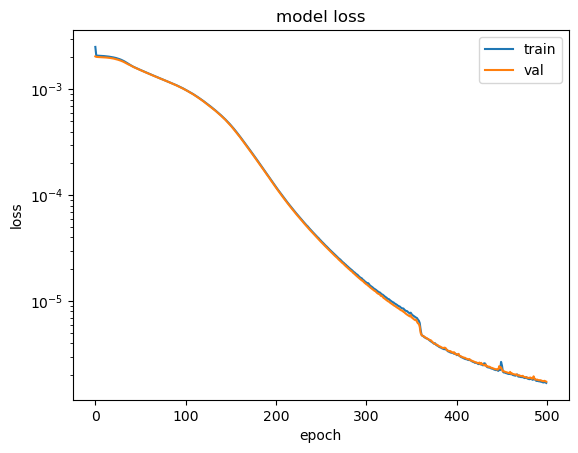

In [50]:
plt.plot(hist.history["loss"])
plt.plot(hist.history["val_loss"])
plt.title("model loss")
plt.ylabel("loss")
plt.xlabel("epoch")
plt.legend(["train", "val"])
plt.yscale("log")
np.set_printoptions(linewidth=np.inf)
layer = model.get_layer("log_rates")  # or model.layers[0]
weights, biases = layer.get_weights()

print("Exp Biases:", np.exp(biases))
weights = np.array(weights)
print("Weights:\n", weights)
print("Max weights:", np.max(weights.T, axis=1))
# print("Exp Weights:\n", np.exp(weights))
x = np.array([[1, 0]] * seq_length).reshape(1, seq_length, 2)  # Template input
activation = Model(inputs=model.input, outputs=model.get_layer("log_rates").output)
activation_output = activation.predict(x)
print("Matching Rates:", np.exp(activation_output))
y = model.predict(x)
print("Activity:", y)
xoff = x.copy()
xoff[:,0]=np.array([0,1])
print("Missmatching Rates:", np.exp(activation.predict(xoff)))
print("Missmatch activity:", model.predict(xoff))

In [ ]:
%load_ext watermark
%watermark -n -u -v -iv -w

Last updated: Fri Jul 04 2025

Python implementation: CPython
Python version       : 3.7.3
IPython version      : 7.33.0

numpy     : 1.18.5
scipy     : 1.5.3
matplotlib: 3.5.1
pandas    : 1.3.5
sklearn   : 1.0.2
tensorflow: 1.14.0
seaborn   : 0.12.2

Watermark: 2.5.0

